In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Regression dataset
housing = fetch_california_housing()
X_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
y_reg = housing.target

# Classification dataset
cancer = load_breast_cancer()
X_clf = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_clf = cancer.target

In [3]:
print(X_reg.shape)
print(X_reg.head())
print(X_reg.describe())
print(X_reg.isnull().sum())

print(X_clf.shape)
print(X_clf.describe())

(20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716

In [4]:
scaler = StandardScaler()

X_reg_scaled = scaler.fit_transform(X_reg)
X_clf_scaled = scaler.fit_transform(X_clf)

In [5]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf_scaled, y_clf, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(Xr_train, yr_train)

pred = model.predict(Xr_test)

mse = mean_squared_error(yr_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, pred)

print(mse, rmse, r2)

0.555891598695244 0.7455813830127761 0.5757877060324511


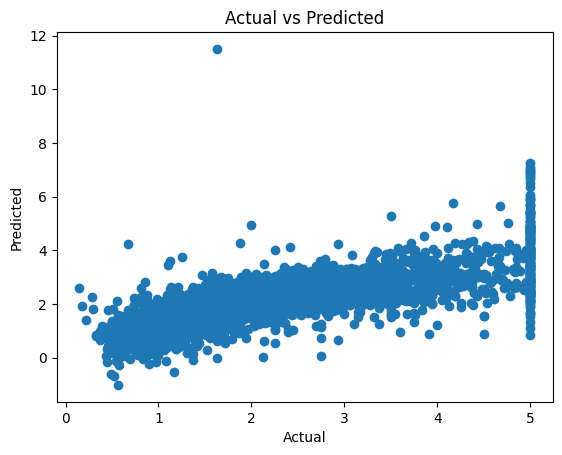

In [7]:
plt.scatter(yr_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [8]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, m in models.items():
    m.fit(Xr_train, yr_train)
    p = m.predict(Xr_test)
    print(name, r2_score(yr_test, p))

Ridge 0.575818534544132
Decision Tree 0.6257367644031518
Random Forest 0.806861482579851


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf = LogisticRegression(max_iter=10000)
clf.fit(Xc_train, yc_train)

pred = clf.predict(Xc_test)

print("Accuracy:", accuracy_score(yc_test, pred))
print(confusion_matrix(yc_test, pred))
print(classification_report(yc_test, pred))

Accuracy: 0.9736842105263158
[[41  2]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [10]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(Xc_train, yc_train)

pred_dt = dt.predict(Xc_test)
print("DT Accuracy:", accuracy_score(yc_test, pred_dt))

DT Accuracy: 0.9298245614035088


In [11]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(Xc_train, yc_train)

pred_nb = nb.predict(Xc_test)
print("NB Accuracy:", accuracy_score(yc_test, pred_nb))

NB Accuracy: 0.9649122807017544


In [12]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [3,5,10]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xc_train, yc_train)
    pred_knn = knn.predict(Xc_test)
    print(f"K={k} Accuracy:", accuracy_score(yc_test, pred_knn))

K=3 Accuracy: 0.9473684210526315
K=5 Accuracy: 0.9473684210526315
K=10 Accuracy: 0.956140350877193


In [13]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear')
svm_rbf = SVC(kernel='rbf')

svm_linear.fit(Xc_train, yc_train)
svm_rbf.fit(Xc_train, yc_train)

print("SVM Linear:", accuracy_score(yc_test, svm_linear.predict(Xc_test)))
print("SVM RBF:", accuracy_score(yc_test, svm_rbf.predict(Xc_test)))

SVM Linear: 0.956140350877193
SVM RBF: 0.9736842105263158


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(Xc_train, yc_train)

print("RF:", accuracy_score(yc_test, rf.predict(Xc_test)))

RF: 0.9649122807017544


In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(Xc_train, yc_train)

print("GB:", accuracy_score(yc_test, gb.predict(Xc_test)))

GB: 0.956140350877193


In [16]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[
    ('lr', clf),
    ('rf', rf),
    ('svm', svm_rbf)
], voting='hard')

voting.fit(Xc_train, yc_train)
print("Voting:", accuracy_score(yc_test, voting.predict(Xc_test)))

Voting: 0.9824561403508771


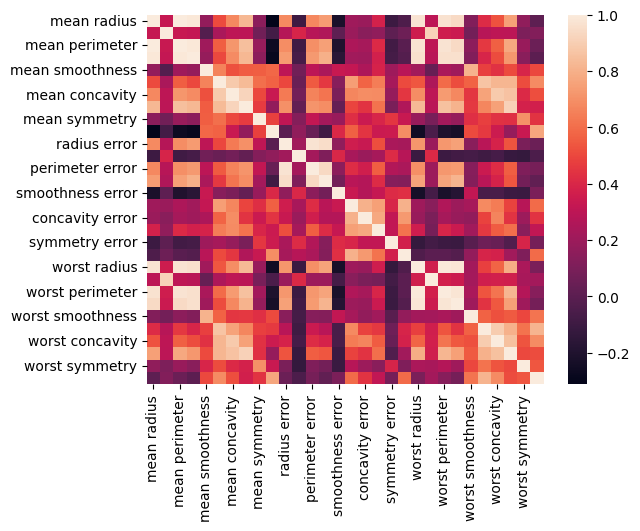

In [17]:
sns.heatmap(X_clf.corr())
plt.show()

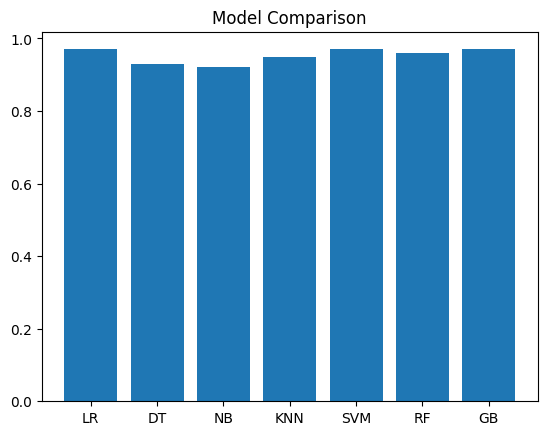

In [18]:
models = ["LR","DT","NB","KNN","SVM","RF","GB"]
acc = [0.97,0.93,0.92,0.95,0.97,0.96,0.97]

plt.bar(models, acc)
plt.title("Model Comparison")
plt.show()